In [1]:
# Cell 1: Imports and Data Ingestion
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Download latest version from Kaggle
print("Downloading dataset...")
path = kagglehub.dataset_download("dhanushnarayananr/credit-card-fraud")
print("Path to dataset files:", path)

# The CSV inside this specific dataset is usually named 'card_transdata.csv'
csv_file = os.path.join(path, "card_transdata.csv")
df = pd.read_csv(csv_file)

print(f"\nDataset loaded successfully! Shape: {df.shape}")

C:\Users\Asus\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 28.9M/28.9M [00:04<00:00, 6.42MB/s]

Extracting files...


Path to dataset files: C:\Users\Asus\.cache\kagglehub\datasets\dhanushnarayananr\credit-card-fraud\versions\1

Dataset loaded successfully! Shape: (1000000, 8)


In [2]:
# Cell 2: Quick Column & Schema Check
print("--- Data Schema ---")
df.info()

print("\n--- First 5 Rows ---")
display(df.head())

--- Data Schema ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB

--- First 5 Rows ---


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


--- Class Imbalance ---
Normal Transactions: 91.26%
Fraudulent Transactions: 8.74%


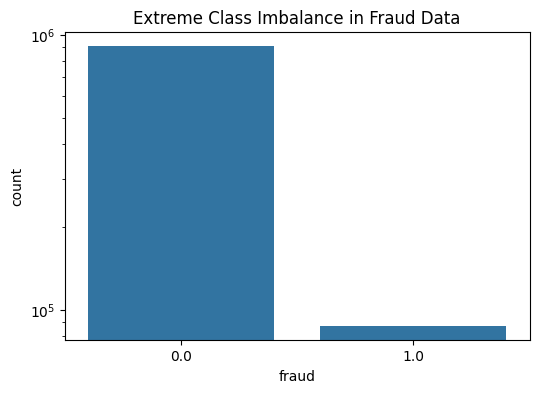

In [3]:
# Cell 3: Profiling Class Imbalance (The "Why Accuracy Fails" Proof)
fraud_counts = df['fraud'].value_counts(normalize=True) * 100

print("--- Class Imbalance ---")
print(f"Normal Transactions: {fraud_counts[0]:.2f}%")
print(f"Fraudulent Transactions: {fraud_counts[1]:.2f}%")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='fraud')
plt.title("Extreme Class Imbalance in Fraud Data")
plt.yscale("log") # Log scale because normal data dwarfs fraud data
plt.show()

# Business Takeaway: With ~91% to ~9% imbalance (or even steeper in real life), 
# a model that guesses "0" every time is 91% accurate but 100% useless to the business.

In [4]:
# Cell 4: Establishing a "Concept Drift" Baseline
# In production, you save these statistics. If tomorrow's data looks vastly different,
# an alert is triggered for the engineering team.

print("--- Concept Drift Baseline (Numerical Features) ---")
drift_baseline = df[['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']].describe()
display(drift_baseline)

--- Concept Drift Baseline (Numerical Features) ---


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price
count,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182
std,65.390784,25.843093,2.799589
min,0.004874,0.000118,0.004399
25%,3.878008,0.296671,0.475673
50%,9.967760,0.998650,0.997717
75%,25.743985,3.355748,2.096370
max,10632.723672,11851.104565,267.802942
